# Forward forecast intervals

A bootstrap usually answers a question about the *past*: how uncertain is a
statistic computed on the data you already have. `forecast_intervals` answers a
question about the *future*: given a fitted model, what is a plausible range for
the next few values of the series.

The idea is simulation. Fit an autoregressive model once, then run it `horizon`
steps past the end of the data many times, each run driven by a fresh sequence of
innovations resampled from the model residuals. That gives many possible future
paths. The interval at each step is the empirical quantiles of those paths.

Below we build a forecast fan, check its coverage against fresh future paths, and
trace how the interval width grows with the horizon. One limitation worth stating up
front: `forecast_intervals` supports AR models only and refuses ARIMA or VAR.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## How a forward interval is built

`forecast_intervals(X, model=AR(order=p), horizon=H, alpha=...)` does five things:

1. Fit an AR(p) to `X` and keep its coefficients and residuals.
2. Center the residuals (subtract their mean) to form an innovation pool.
3. For each of `n_bootstraps` replicates, draw `H` innovations from that pool and
   run the fitted recursion `H` steps forward, starting from the last `p`
   observations of `X`.
4. Stack the replicate paths into an `(n_bootstraps, H)` array.
5. Read the per-step quantiles: `alpha/2` for the lower band, `1 - alpha/2` for the
   upper band, and `0.5` for the median.

The return value is a tuple `(lower, upper, median)`, each a 1-D array of length
`horizon`. Coverage here rests on large-sample behaviour of the fitted model under serial
dependence; it is not the exact, finite-sample kind you get from exchangeable data,
which is exactly why the empirical checks below matter.

## Data and helpers

A small AR(2) data-generating process, the bundled lynx series from sktime, and a
coverage Monte-Carlo.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tsbootstrap import forecast_intervals, AR, ARIMA, VAR
from tsbootstrap.errors import MethodConfigError

PHI = (0.5, -0.3)  # stationary AR(2) coefficients we will reuse as ground truth
P = len(PHI)


def ar2(n, rng, phi=PHI, burn=100):
    """Stationary AR(2) with unit-variance Gaussian noise, true mean 0."""
    z = np.zeros(n + burn)
    e = rng.standard_normal(n + burn)
    for t in range(len(phi), n + burn):
        z[t] = phi[0] * z[t - 1] + phi[1] * z[t - 2] + e[t]
    return z[burn:]

## An AR forecast fan on the lynx series

The Canadian lynx series is a classic short, cyclical record of annual pelt
counts. Counts are strictly positive and the cycles are sharp, so we model the
series on the log scale, where an AR fit behaves better, then exponentiate the
bands back to the original count scale for plotting.

We hold out the last few years so the fan can be compared against what actually
happened.

In [3]:
from sktime.datasets import load_lynx

lynx = np.asarray(load_lynx(), dtype=float)
log_lynx = np.log(lynx)

HOLDOUT = 8
train = log_lynx[:-HOLDOUT]
actual = lynx[-HOLDOUT:]  # the held-out years, on the original count scale

lo_log, up_log, med_log = forecast_intervals(
    train, model=AR(order=4), horizon=HOLDOUT, alpha=0.1, random_state=0
)
lo, up, med = np.exp(lo_log), np.exp(up_log), np.exp(med_log)
print('forecast horizon:', HOLDOUT)
print('lower/upper/median shapes:', lo.shape, up.shape, med.shape)
print('90%% band, year ahead +1: [%.0f, %.0f] pelts' % (lo[0], up[0]))

forecast horizon: 8
lower/upper/median shapes: (8,) (8,) (8,)
90% band, year ahead +1: [601, 3563] pelts


The fan below shows the tail of the training series, the 90 percent forecast band
fanning out over the holdout, the forecast median, and the values that actually
occurred. Read the band rather than the median: lynx cycles are hard, and an AR
model captures only the linear part of the dynamics, so the median can miss a turn
while the band still covers the outcome.

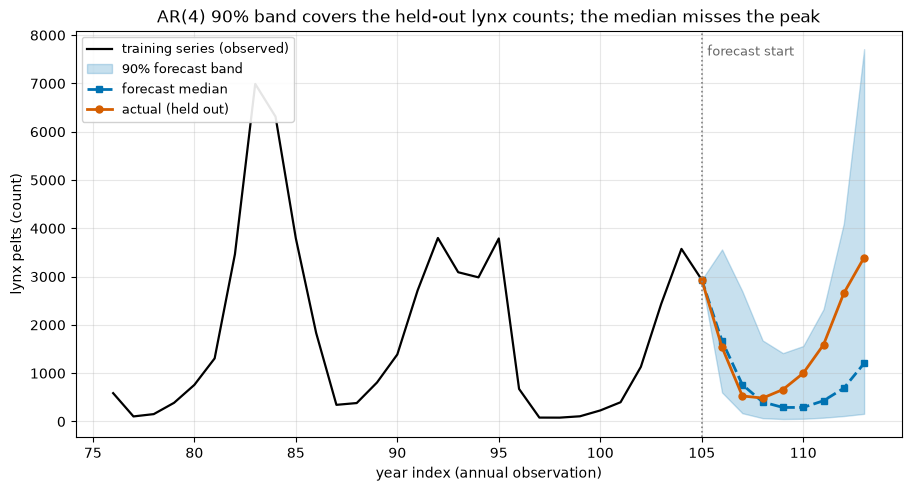

In [4]:
tail = 30
years = np.arange(len(lynx))
train_years = years[:-HOLDOUT]
fut_years = years[-HOLDOUT:]

# Anchor the forecast at the last observed training point so the fan, the median,
# and the actuals all start from the data rather than floating one step to the right.
anchor_year = train_years[-1]
anchor_val = lynx[:-HOLDOUT][-1]
band_years = np.concatenate(([anchor_year], fut_years))
lo_p = np.concatenate(([anchor_val], lo))
up_p = np.concatenate(([anchor_val], up))
med_p = np.concatenate(([anchor_val], med))
act_p = np.concatenate(([anchor_val], actual))

# Okabe-Ito colorblind-safe palette.
C_TRAIN = "#000000"
C_FCST = "#0072B2"  # blue
C_ACTUAL = "#D55E00"  # vermillion

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
ax.plot(train_years[-tail:], lynx[:-HOLDOUT][-tail:], color=C_TRAIN, lw=1.6,
        label="training series (observed)")
ax.fill_between(band_years, lo_p, up_p, color=C_FCST, alpha=0.22,
                label="90% forecast band")
ax.plot(band_years, med_p, color=C_FCST, lw=2.0, ls="--", marker="s", ms=4,
        label="forecast median")
ax.plot(band_years, act_p, color=C_ACTUAL, lw=2.0, marker="o", ms=5,
        label="actual (held out)")
ax.axvline(anchor_year, color="0.5", ls=":", lw=1.2)
ax.annotate("forecast start", xy=(anchor_year, ax.get_ylim()[1]),
            xytext=(4, -10), textcoords="offset points",
            color="0.4", fontsize=9, ha="left", va="top")
ax.set_xlabel("year index (annual observation)")
ax.set_ylabel("lynx pelts (count)")
ax.set_title("AR(4) 90% band covers the held-out lynx counts; the median misses the peak")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="upper left", framealpha=0.9)
plt.show()

The band widens as it reaches further ahead, and it stays wide throughout. A
short, sharply cyclical series carries a lot of forward uncertainty, and the
simulation passes that uncertainty straight into the band rather than collapsing
it onto a tight point forecast.

## Does the band cover at the nominal rate?

A 90 percent band should contain the truth about 90 percent of the time. On a
synthetic AR(2) we can measure that directly, because we know the process that
generates the future.

The recipe: fit one band from a single realisation, then draw many *fresh* future
paths from the same true AR(2), continuing from the same last `P` observations, and
count how often each future value lands inside the band. With nominal `1 - alpha`,
the per-step hit rate should sit near `1 - alpha`. The Monte-Carlo below uses a
modest number of paths so it stays fast in CI.

In [5]:
rng = np.random.default_rng(0)
n, H, alpha = 400, 8, 0.2  # 80% nominal coverage
x = ar2(n, rng)

lo_c, up_c, med_c = forecast_intervals(
    x, model=AR(order=2), horizon=H, alpha=alpha, n_bootstraps=999, random_state=0
)

M = 2000  # fresh future paths
last = x[-P:]
hits = np.zeros(H)
for _ in range(M):
    path = np.empty(H + P)
    path[:P] = last
    e = rng.standard_normal(H)
    for h in range(H):
        path[P + h] = PHI[0] * path[P + h - 1] + PHI[1] * path[P + h - 2] + e[h]
    future = path[P:]
    hits += ((future >= lo_c) & (future <= up_c)).astype(float)

coverage = hits / M
print('per-step coverage:', np.round(coverage, 3))
print('mean coverage:    %.3f   (nominal %.2f)' % (coverage.mean(), 1 - alpha))

per-step coverage: [0.78  0.815 0.762 0.774 0.799 0.794 0.783 0.784]
mean coverage:    0.786   (nominal 0.80)


The mean coverage lands close to the nominal 0.80. It will not match exactly: the
band is read from a single fitted realisation, so it inherits that realisation's
sampling noise, and bootstrap forecast coverage is asymptotic rather than exact.
A result this close to nominal is what calibrated bands look like.

## Uncertainty grows with the horizon

Each step forward compounds the innovation drawn at that step on top of all the
uncertainty already accumulated, so the interval should widen monotonically (up to
simulation noise) as the horizon grows. We read the band width straight off a
single longer forecast.

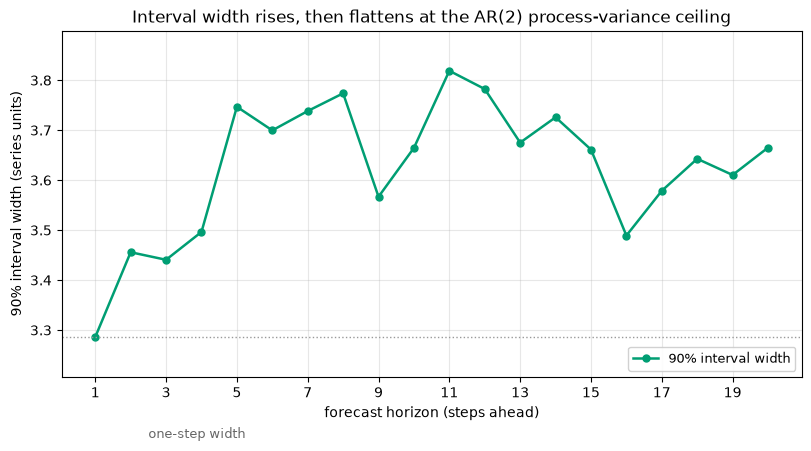

width at step 1: 3.29
width at step 20: 3.67


In [6]:
rng = np.random.default_rng(1)
x_long = ar2(600, rng)
H_long = 20
lo_w, up_w, _ = forecast_intervals(
    x_long, model=AR(order=2), horizon=H_long, alpha=0.1,
    n_bootstraps=999, random_state=1
)
width = up_w - lo_w
steps = np.arange(1, H_long + 1)

fig, ax = plt.subplots(figsize=(8, 4.4), layout="constrained")
ax.plot(steps, width, "o-", color="#009E73", lw=1.8, ms=5,  # Okabe-Ito green
        label="90% interval width")
# Mark the one-step width and the long-horizon plateau so the rise is legible.
ax.axhline(width[0], color="0.6", ls=":", lw=1.0)
ax.annotate("one-step width", xy=(1, width[0]), xytext=(2.5, width[0] - 0.18),
            color="0.4", fontsize=9, va="top")
ax.set_xlabel("forecast horizon (steps ahead)")
ax.set_ylabel("90% interval width (series units)")
ax.set_title("Interval width rises, then flattens at the AR(2) process-variance ceiling")
ax.set_xticks(steps[::2])
ax.margins(y=0.15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="lower right", framealpha=0.9)
plt.show()

print('width at step 1: %.2f' % width[0])
print('width at step %d: %.2f' % (H_long, width[-1]))

The width climbs from the one-step value and flattens out. The flattening is
expected for a stationary AR: the forecast variance converges to the process
variance as the horizon grows, so the band approaches a finite ceiling rather than
widening without bound. A non-stationary process (a random walk, say) would not
level off, but `forecast_intervals` rejects unstable fits before it gets that far.

## Supported models: AR only

`forecast_intervals` currently supports AR models and nothing else. Passing an
ARIMA or VAR specification raises `MethodConfigError` right away instead of
returning an approximate result. The cell below calls it with each unsupported
model inside a `try/except` and prints the error it raises.

In [7]:
for model in (ARIMA(order=(1, 1, 1)), VAR(order=1)):
    try:
        forecast_intervals(x, model=model, horizon=5)
    except MethodConfigError as err:
        print('%-6s ->' % type(model).__name__, err)

ARIMA  -> [TSB_UNSUPPORTED_MODEL_FEATURE] forecast_intervals currently supports an AR model; got ARIMA
VAR    -> [TSB_UNSUPPORTED_MODEL_FEATURE] forecast_intervals currently supports an AR model; got VAR


Both calls raise `MethodConfigError` with the code `TSB_UNSUPPORTED_MODEL_FEATURE`.
Out-of-sample forecast intervals for ARIMA and VAR are planned for a later release.
Until then the function raises rather than returning an unvalidated band.

If you need a rough forward band for a non-AR model today, you can drive it
yourself from bootstrap replicates: fit your model, simulate forward paths from
resampled innovations, and take per-step quantiles, which is the recipe
`forecast_intervals` automates for the AR case. That is a manual workaround, not a
supported API, and it carries the same asymptotic-coverage caveats shown above, so
treat its output as indicative rather than calibrated.

## The forecast fan in one paragraph

A forward band is nothing more than many simulated futures read off at per-step
quantiles: call `forecast_intervals(X, model=AR(order=p), horizon=H, alpha=...)` and
you get back `(lower, upper, median)`, each of length `H`. On the synthetic AR(2) the
bands cover close to nominal against fresh paths, and they fan out with the horizon
until they hit the process-variance ceiling. For now the function is AR-only and
raises `MethodConfigError` for ARIMA or VAR; wider model support is on the roadmap.